## Workshop on Genetics

by Kaylee Vo and Tadhg Scannell

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from collections import defaultdict

In [2]:
# Customize for matplotlib
# If interested in the matplotlib object hierarchy, check: https://realpython.com/python-matplotlib-guide/
plt.rcParams["axes.linewidth"] = 1
plt.rcParams["xtick.bottom"] = True
plt.rcParams["ytick.left"] = True
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["mathtext.default"] = "regular"
# Change font size: http://www.futurile.net/2016/02/27/matplotlib-beautiful-plots-with-style/
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 14
plt.rcParams["figure.titlesize"] = 20

### Problem 1

**Define the states and construct the transition matrix of the system, in canonical form.**

The states are $\{HH, HM, HY, YY, YM, MM\}$ For our convention, the columns will be the current state and the rows will be the next state. The transition matrix will be 6x6, in the following order of states: `[HH, HM, HY, YY, YM, MM]`. Since the problem requires that we put the transition matrix in canonical form, we order the states such that absorbing states come first, followed by non-absorbing states. That is why $HH, HM, HY$ are the first three states and the other can come in any order after.

In [3]:
# HH, YY, HM, HY, YM, MM
transition_matrix = np.array(
    [
        [1, 0, 1 / 4, 0, 0, 1 / 16],
        [0, 1, 0, 0, 1 / 4, 1 / 16],
        [0, 0, 1 / 2, 0, 0, 1 / 4],
        [0, 0, 0, 0, 0, 1 / 8],
        [0, 0, 0, 0, 1 / 2, 1 / 4],
        [0, 0, 1 / 4, 1, 1 / 4, 1 / 4],
    ]
)

In [4]:
# Sanity check to make sure the columns sum to 1
assert np.all(np.sum(transition_matrix, axis=0) == 1)

#### Computing the Transition Probabilities
*Note: Feel free to skip*

To find the transition matrix values, we start with the easy cases, $HH, HY ~\text{and}~ YY$. The punnet squares for each of these only yield one possible outcome so the transition matrix values will be 1. For HH and YY, they are terminating states that loop back to themselves. For HY, it will always transition to MM.

Next, we tackle the semi-difficult cases $HM$ and $YM$. For $HM$, there is a 50% of the offspring being $H$ or $M$. With the marriage restriction, we repeat this probability branch to arrive at 0.25 for $HH$, 0.5 for $HM$, and 0.25 for $MM$. By symmetry, we see that this is true for $YM$ as well. For this case, we have 0.25 for $YY$, 0.5 for $YM$, and 0.25 for $MM$. The probability tree is shown below.

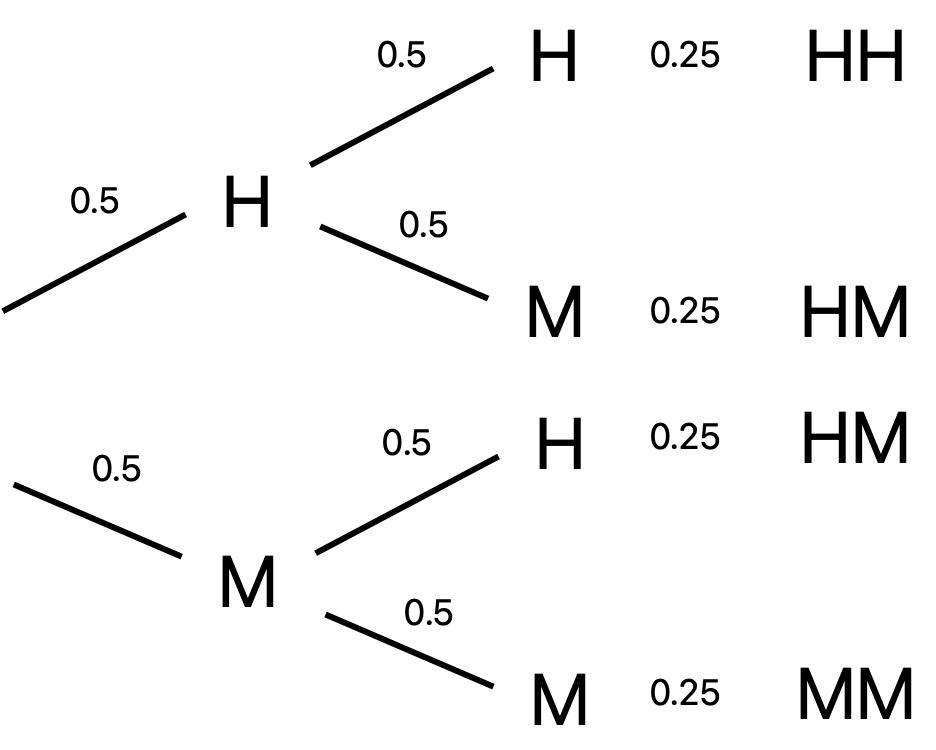

In [5]:
image_path = "./plots/probability_tree.png"
display(Image(image_path, width=400))

Finally, we tackle the most difficult case, $MM$. The punnet square for this is a bit more complicated. We have 1/4 chance of getting $H$, 1/2 chance of getting $M$, and 1/4 chance of getting $Y$. We can use the probability tree strategy above to find the transition matrix probabilities. For brevity sake we will not show the full tree here, but after computing the entire tree we get, `{HH: 1/16, HM: 1/4, HY: 1/8, YY: 1/16, YM: 1/4, MM: 1/4}`. A visual diagram of the complete Markov chain is shown below.

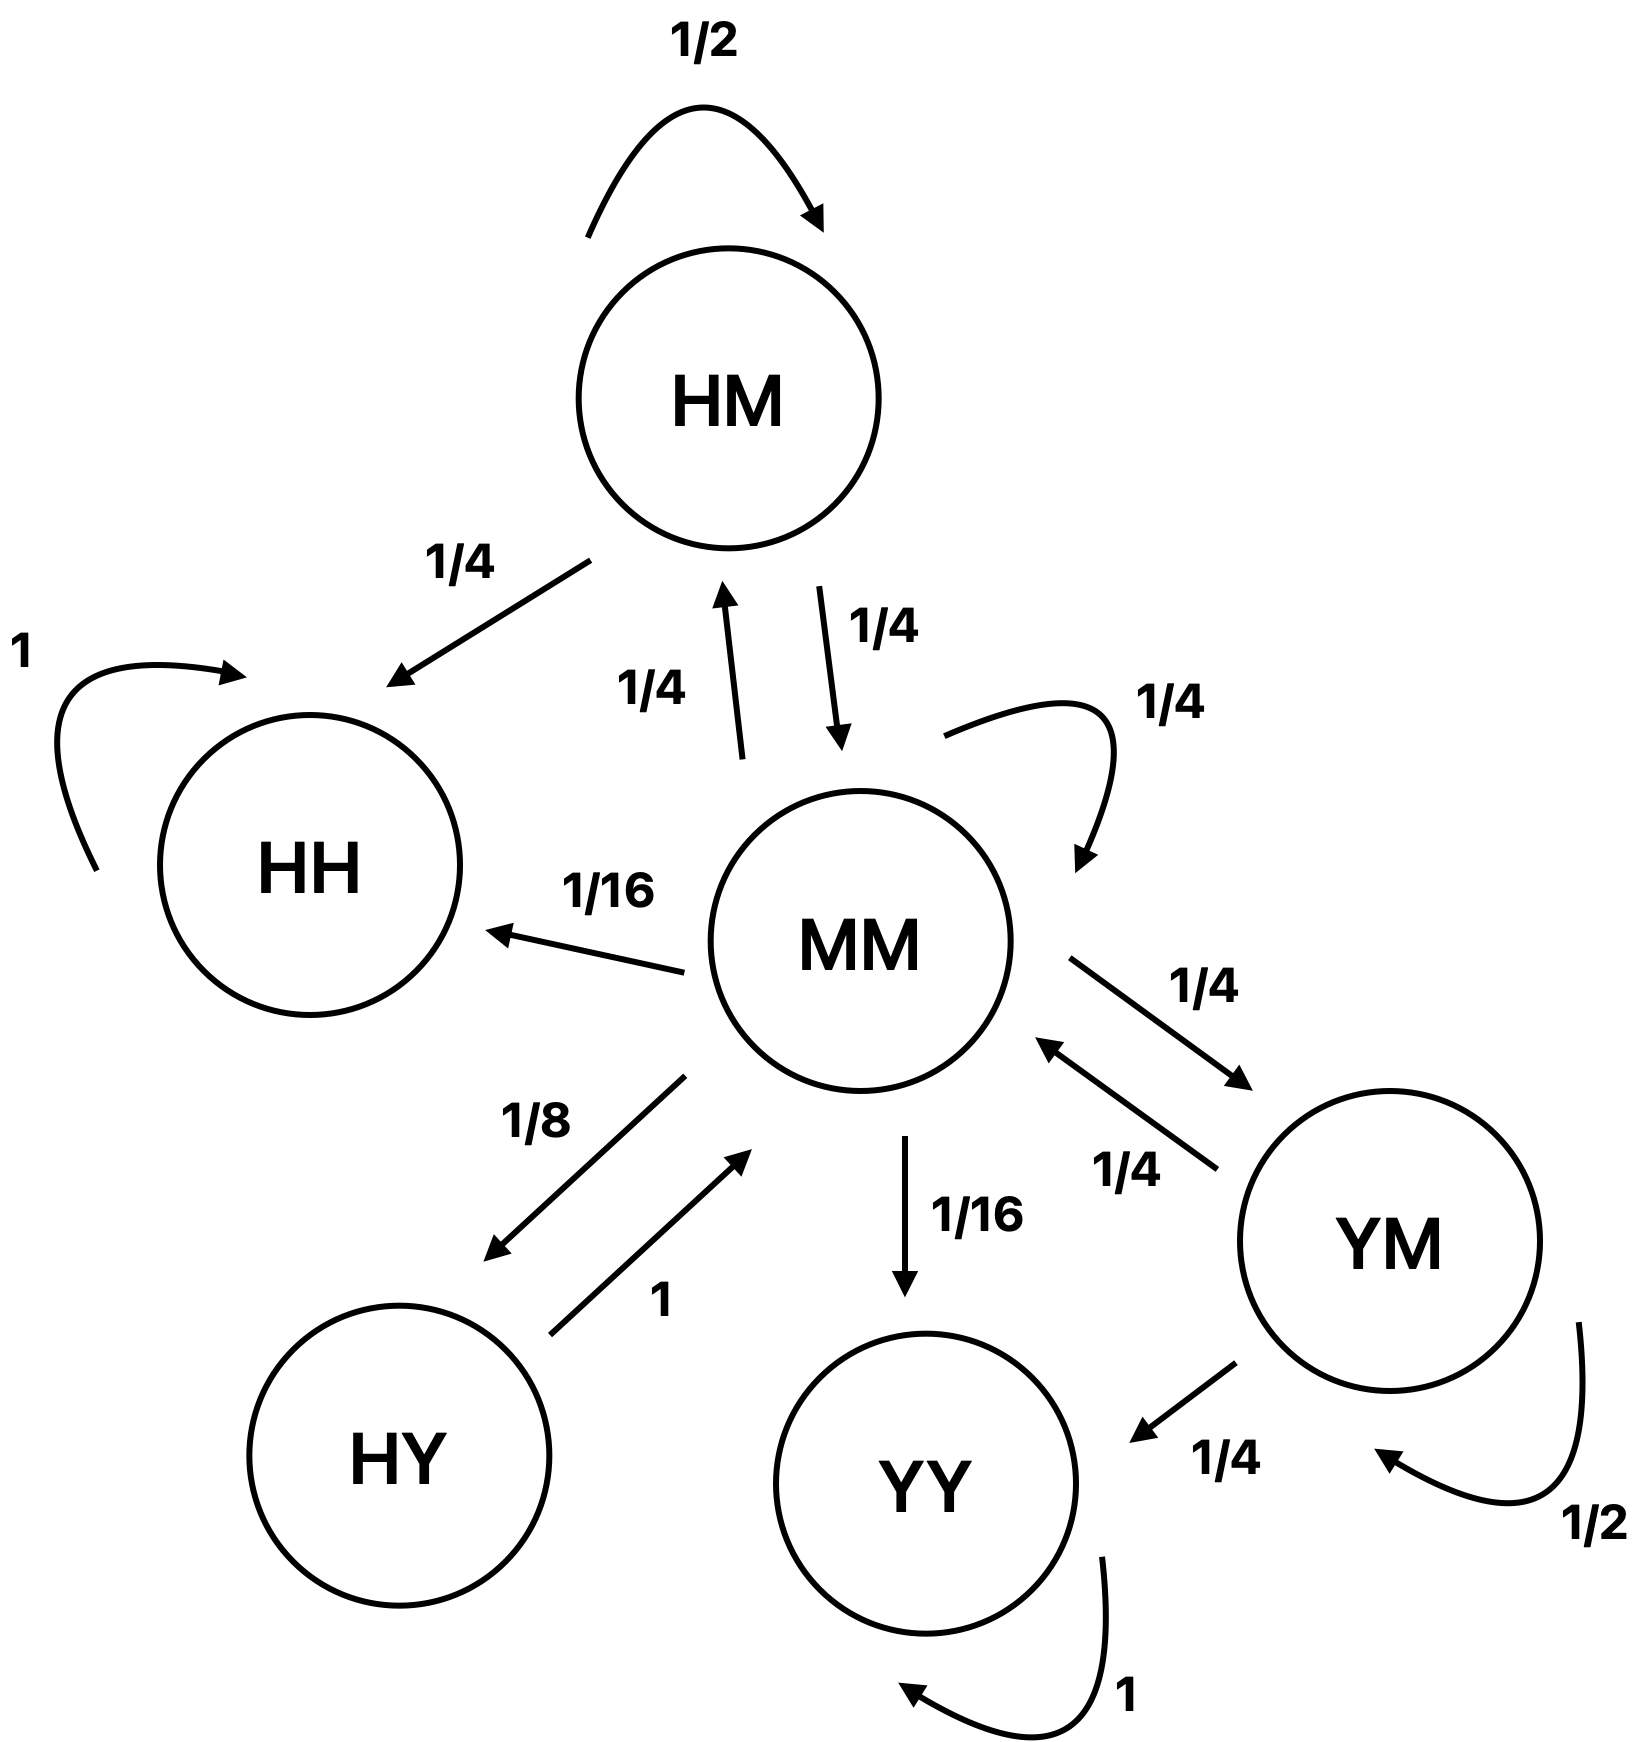

In [6]:
image_path = "./plots/genetics_markov_chain.png"
display(Image(image_path, width=400))

### Problem 2

**Numerically evolve the probability vector (i.e. multiply the probability vector by the 
transition matrix) to equilibrium for some different initial conditions as prescribed below. How does the initial size of the student populations affect the final probabilities? Try:** 

#### i. equal number of people of a certain phenotype: Y = 1/2, H = 1/4, M = 1/4

Let's first construct the probability vector for this initial size. Since we're assuming the first generation are open minded and marry within the population randomly, all possible combinations of $H$, $Y$, and $M$ are equally likely. 

In [7]:
hh = 1 / 4
hy = 1 / 4
yy = 1 / 2

In [8]:
# HH, YY, HM, HY, YM, MM
# Assumes that first generation mix randomly
probability_vector = [
    hh * hh,
    yy * yy,
    hh * hy + hy * hh,
    hh * yy + yy * hh,
    yy * hy + hy * yy,
    hy * hy,
]
probability_vector = np.array(probability_vector)

probability_vector

array([0.0625, 0.25  , 0.125 , 0.25  , 0.25  , 0.0625])

Now, we numerically evolve the probability vector. Since the transition matrix was constructed with the restriction that children only marry others who's parents were of the same genotyp, it implicitly imposes this restriction. First generation is random, but all generations after are not.

In [9]:
# Number of iterations
n_iter = 1000000

for i in range(n_iter):
    probability_vector = transition_matrix @ probability_vector

# print the final probabilities
states = ["HH", "YY", "HM", "HY", "YM", "MM"]
dict(zip(states, probability_vector))

{'HH': 0.37500000000000017,
 'YY': 0.6249999999999992,
 'HM': 1.5e-323,
 'HY': 0.0,
 'YM': 1.5e-323,
 'MM': 1.5e-323}

In this scenario, the probability vector arrives as an equilibrium where $HH$ is 0.375 and $YY$ is 0.625. The $M$ genotype will eventually die out. 

#### ii. equal number of people of a certain genotype: Y = 1/3, H = 1/3, M = 1/3

Now we change the initial values.

In [10]:
hh = 1 / 3
hy = 1 / 3
yy = 1 / 3

In [11]:
# ["HH", "YY", "HM", "HY", "YM", "MM"]
# assume that first generation are open minded
probability_vector = [
    hh * hh,
    yy * yy,
    hh * hy + hy * hh,
    hh * yy + yy * hh,
    yy * hy + hy * yy,
    hy * hy,
]
probability_vector = np.array(probability_vector)
probability_vector

array([0.11111111, 0.11111111, 0.22222222, 0.22222222, 0.22222222,
       0.11111111])

In [12]:
n_iter = 1000000

for i in range(n_iter):
    probability_vector = transition_matrix @ probability_vector

# print the final probabilities
states = ["HH", "YY", "HM", "HY", "YM", "MM"]
dict(zip(states, probability_vector))

{'HH': 0.4999999999999995,
 'YY': 0.4999999999999995,
 'HM': 1.5e-323,
 'HY': 0.0,
 'YM': 1.5e-323,
 'MM': 1.5e-323}

In this scenario, the probability vector arrives as an equilibrium where $HH$ and $YY$ are both 0.5. This means that the population will eventually be split evenly between $H$ and $Y$ genotypes. The $M$ genotype will eventually die out. 

The MIT scientist claims that eventually one of the institutions $H$ or $Y$ will dominate the population and one institution will die out. This is not true because the equilibrium shown above shows that both $HH$ and $YY$ exist in the population equlibrium. The $M$ genotype dies out and the population eventually reaches a point where all offspring go to Harvard or Yale.

## Problem 3

**Use the fundamental matrix and related analysis approach covered in class to analyze 
this problem. For example, calculate the number of generations to absorption, as well as 
the probability of each outcome as function of the initial state.** 


Let's create the four matrices. Our matrix is already in canonical form, so no need to reorder the states.

In [13]:
I_mat = transition_matrix[:2, :2]
R_mat = transition_matrix[:2, 2:]
Q_mat = transition_matrix[2:, 2:]
O_mat = transition_matrix[2:, :2]

I_mat.shape, R_mat.shape, Q_mat.shape, O_mat.shape

((2, 2), (2, 4), (4, 4), (4, 2))

In [14]:
I_mat

array([[1., 0.],
       [0., 1.]])

In [15]:
R_mat

array([[0.25  , 0.    , 0.    , 0.0625],
       [0.    , 0.    , 0.25  , 0.0625]])

In [16]:
Q_mat

array([[0.5  , 0.   , 0.   , 0.25 ],
       [0.   , 0.   , 0.   , 0.125],
       [0.   , 0.   , 0.5  , 0.25 ],
       [0.25 , 1.   , 0.25 , 0.25 ]])

In [17]:
O_mat

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.]])

#### Generations to Absorption

To compute the expected number of generations to absorption, we can use the fundamental matrix $N = (I - Q)^{-1}$.

In [18]:
# Fundamental matrix
N = np.linalg.inv(np.identity(4) - Q_mat)

In [19]:
# HM, HY, YM, MM
N

array([[2.66666667, 1.33333333, 0.66666667, 1.33333333],
       [0.16666667, 1.33333333, 0.16666667, 0.33333333],
       [0.66666667, 1.33333333, 2.66666667, 1.33333333],
       [1.33333333, 2.66666667, 1.33333333, 2.66666667]])

- The sum of the columns of $N$ gives the expected number of generations until absorption.
- The entries represent the the number of generations within a simulation that you are at a given state.

In [20]:
np.sum(N, axis=0)

array([4.83333333, 6.66666667, 4.83333333, 5.66666667])

- The sum of columns of the fundamental matrix $N$ gives the expected steps spent in each transient state before absorption.
- For example, if you start at $HM$ then you expect to be absorbed in 4.83 generations.


#### Probability of Outcome as Function of the Initial State

To compute the probability of a starting state ending up in an absorbing state, we can use the matrix $B = R \cdot N$.

In [21]:
# Columns are "HM", "HY", "YM", "MM"
# Rows are HH, YY
B = R_mat @ N
B

array([[0.75, 0.5 , 0.25, 0.5 ],
       [0.25, 0.5 , 0.75, 0.5 ]])

- This means that starting at $HM$, the probability of ending up in absorbing state $HH$ is 0.75.

## Problem 4

**Compare your results from 2i and 2ii to a stochastic individual agent simulation: begin with initial set of agents with phenotype or genotype distributions as in 2i and 2ii and keep track of the evolving populations based on the imposed rules. Use a random number generator to decide on probabilistic outcome when needed. Perform many simulations and compare some key statistics to those found from the fundamental matrix.**

### Part A: Repeat Problem 2

Code borrowed from the `model_epidemic1d.ipynb` notebook.

```python

In [ ]:
def random_mixing(hh_init, hy_init, yy_init, N):
    """
    Just like the prior example, we need to randomly mix
    in the first generation of the population. We construct
    the probability vector just like before.
    """

    # HH, YY, HM, HY, YM, MM
    probability_vector = [
        hh_init * hh_init,
        yy_init * yy_init,
        hh_init * hy_init + hy_init * hh_init,
        hh_init * yy_init + yy_init * hh_init,
        yy_init * hy_init + hy_init * yy_init,
        hy_init * hy_init,
    ]
    probability_vector = np.array(probability_vector)
    initial_population_count = np.random.multinomial(N, probability_vector)

    return initial_population_count


def initial1D(hh, yy, hm, hy, ym, mm):
    """After random mixing, we create an initial population.
    We shuffle just for good measure.

    Example list
    pop = ["hh", "hh", "yy", ...]
    """
    pop = []
    pop += ["hh"] * hh
    pop += ["yy"] * yy
    pop += ["hm"] * hm
    pop += ["hy"] * hy
    pop += ["ym"] * ym
    pop += ["mm"] * mm
    np.random.shuffle(pop)
    return pop


def census1D(pop):
    counts = {"hh": 0, "yy": 0, "hm": 0, "hy": 0, "ym": 0, "mm": 0}
    for p in pop:
        if p in counts:
            counts[p] += 1
    return (
        counts["hh"],
        counts["yy"],
        counts["hm"],
        counts["hy"],
        counts["ym"],
        counts["mm"],
    )


def ivyleague1D(pop1):
    pop2 = pop1.copy()

    for j in range(len(pop1)):
        state = pop1[j]
        r = np.random.rand()
        # Absorbing states
        if state == "hh" or state == "yy":
            pop2[j] = state
        # HM State
        elif state == "hm":
            if r < 0.5:  # 1/2 probability
                pop2[j] = "hm"
            elif r < 0.75:  # 1/4 probability (0.75-0.5)
                pop2[j] = "hh"
            else:  # 1/4 probability
                pop2[j] = "mm"
        # HY State
        elif state == "hy":
            pop2[j] = "mm"
        # YM State
        elif state == "ym":
            if r < 0.5:
                pop2[j] = "ym"
            elif r < 0.75:
                pop2[j] = "yy"
            else:
                pop2[j] = "mm"
        # MM State
        elif state == "mm":
            if r < 0.25:
                pop2[j] = "mm"
            elif r < 0.5:
                pop2[j] = "ym"
            elif r < 0.75:
                pop2[j] = "hm"
            elif r < 0.875:
                pop2[j] = "hy"
            elif r < 0.9375:
                pop2[j] = "yy"
            else:
                pop2[j] = "hh"
    return pop2


def simulate1D(N, hh_init, hy_init, yy_init):
    t = 0
    hh, yy, hm, hy, ym, mm = random_mixing(hh_init, hy_init, yy_init, N)
    pop = initial1D(hh, yy, hm, hy, ym, mm)

    hh, yy, hm, hy, ym, mm = census1D(pop)
    results = [[hh, yy, hm, hy, ym, mm]]
    tt = [t]

    while hm + hy + ym + mm > 0:
        pop = ivyleague1D(pop)
        hh, yy, hm, hy, ym, mm = census1D(pop)
        results.append([hh, yy, hm, hy, ym, mm])
        t += 1
        tt.append(t)

    return tt, results

Use the initial condition from 2i.

In [27]:
num_simulations = 100000
hh_0 = 1 / 4
hy_0 = 1 / 4
yy_0 = 1 / 2

In [28]:
t, res = simulate1D(num_simulations, hh_0, hy_0, yy_0)

In [29]:
np.array(res[-1]) / num_simulations

array([0.3767, 0.6233, 0.    , 0.    , 0.    , 0.    ])

- $HH$ = 0.372, $YY$ = 0.628
- The numbers are close to 0.375 and 0.625 found analytically.

Use the initial condition from 2ii.

In [30]:
num_simulations = 100000
hh_0 = 1 / 3
hy_0 = 1 / 3
yy_0 = 1 / 3

In [31]:
t, res = simulate1D(num_simulations, hh_0, hy_0, yy_0)

In [32]:
np.array(res[-1]) / num_simulations

array([0.49896, 0.50104, 0.     , 0.     , 0.     , 0.     ])

- $HH$ = 0.5, $YY$ = 0.5
- The numbers are close to 0.5 and 0.5 found analytically.

### Part B: Repeat Problem 3

Now we simulate the fundamental matrix N using Monte Carlo simulation.

In [ ]:
# For a given starting state, count the number of visits to
# each transient state. Do this simulation N times.


def simulate_state_visits_from_state(state, N=10000):
    transient_states = ["hm", "hy", "ym", "mm"]
    state_indices = {s: i for i, s in enumerate(transient_states)}
    # visits in the order of hm, hy, ym, mm
    visits = np.zeros((N, 4))

    # N is the number of simulations
    for i in range(N):
        current_state = state
        counts = [0, 0, 0, 0]
        while current_state in transient_states:
            idx = state_indices[current_state]
            counts[idx] += 1  # Count this visit
            r = np.random.rand()
            # The transition matrix logic
            if current_state == "hm":
                if r < 0.5:
                    current_state = "hm"
                elif r < 0.75:
                    current_state = "hh"
                else:
                    current_state = "mm"
            elif current_state == "hy":
                current_state = "mm"
            elif current_state == "ym":
                if r < 0.5:
                    current_state = "ym"
                elif r < 0.75:
                    current_state = "yy"
                else:
                    current_state = "mm"
            elif current_state == "mm":
                if r < 0.25:
                    current_state = "mm"
                elif r < 0.5:
                    current_state = "ym"
                elif r < 0.75:
                    current_state = "hm"
                elif r < 0.875:
                    current_state = "hy"
                elif r < 0.9375:
                    current_state = "yy"
                else:
                    current_state = "hh"
        visits[i] = counts

    # Average the number of visits for each transient state
    return np.mean(visits, axis=0)

In [34]:
col1 = simulate_state_visits_from_state("hm", N=100000)
col2 = simulate_state_visits_from_state("hy", N=100000)
col3 = simulate_state_visits_from_state("ym", N=100000)
col4 = simulate_state_visits_from_state("mm", N=100000)

# HM, HY, YM, MM
N_sim = np.transpose(np.array([col1, col2, col3, col4]))
N_sim

array([[2.66035, 1.33733, 0.66557, 1.33358],
       [0.16609, 1.33364, 0.16574, 0.33299],
       [0.67389, 1.34333, 2.6654 , 1.32532],
       [1.3348 , 2.677  , 1.33246, 2.65946]])

In [35]:
# Analytical N
# array([[2.66666667, 1.33333333, 0.66666667, 1.33333333],
#        [0.16666667, 1.33333333, 0.16666667, 0.33333333],
#        [0.66666667, 1.33333333, 2.66666667, 1.33333333],
#        [1.33333333, 2.66666667, 1.33333333, 2.66666667]])

In [36]:
np.sum(N_sim, axis=0)

array([4.83513, 6.6913 , 4.82917, 5.65135])

In [37]:
# Sum of columns of analytical N
# HM, HY, YM, MM
# array([4.83333333, 6.66666667, 4.83333333, 5.66666667])

- Comparing the analytical $N$ to the simulated $N$, we find that the numbers are very close.
- The commented out code is the analytical $N$.

Now we simulate the $B$ matrix.

In [ ]:
def simulate_B_matrix(N_sim=10000):
    transient_states = ["hm", "hy", "ym", "mm"]
    absorbing_states = ["hh", "yy"]
    # Maps transient states to indices
    # e.g. {'hm': 0, 'hy': 1, 'ym': 2, 'mm': 3}
    state_to_idx = {s: i for i, s in enumerate(transient_states)}
    # Rows are HM, HY, YM, MM
    # columns are HH, YY
    B_counts = np.zeros((4, 2))

    for start_state in transient_states:
        for _ in range(N_sim):
            current_state = start_state

            while current_state not in absorbing_states:
                r = np.random.rand()

                # Copy and paste the transition logic
                # from prior
                if current_state == "hm":
                    if r < 0.5:
                        current_state = "hm"
                    elif r < 0.75:
                        current_state = "hh"
                    else:
                        current_state = "mm"
                elif current_state == "hy":
                    current_state = "mm"
                elif current_state == "ym":
                    if r < 0.5:
                        current_state = "ym"
                    elif r < 0.75:
                        current_state = "yy"
                    else:
                        current_state = "mm"
                elif current_state == "mm":
                    if r < 0.25:
                        current_state = "mm"
                    elif r < 0.5:
                        current_state = "ym"
                    elif r < 0.75:
                        current_state = "hm"
                    elif r < 0.875:
                        current_state = "hy"
                    elif r < 0.9375:
                        current_state = "yy"
                    else:
                        current_state = "hh"

            # Record absorption outcome
            if current_state == "hh":
                B_counts[state_to_idx[start_state], 0] += 1
            else:
                B_counts[state_to_idx[start_state], 1] += 1

    # Normalize to get the probabilities
    return B_counts / N_sim

In [39]:
# B = R_mat @ N
np.transpose(simulate_B_matrix(N_sim=10000))

array([[0.7489, 0.5023, 0.2568, 0.4983],
       [0.2511, 0.4977, 0.7432, 0.5017]])

In [40]:
# array([[0.75, 0.5 , 0.25, 0.5 ],
#        [0.25, 0.5 , 0.75, 0.5 ]])

- The same results hold for $B$ matrix, which gives the probability of ending up in an absorbing state given a starting state.
- The simulated $B$ matrix is very close to the analytical $B$ matrix.